 # Brain Tumor Segmentation — Model Evaluation (fold_all)

 **Model:** nnUNet 2D (PlainConvUNet, 8 stages)

 **Fold:** fold_all (trained on full dataset)

 **Dataset:** Brain Tumor MRI Segmentation (binary: background / tumor)

In [1]:
import json, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path


In [2]:
# Paths
BASE_DIR     = Path('/Users/namnguyen/PycharmProjects/brain_seg_research')
VAL_DIR      = BASE_DIR / 'fold_all' / 'validation'
SUMMARY_FILE = VAL_DIR / 'summary.json'
IMG_DIR      = BASE_DIR / 'raw_kaggle_data' / 'images'
MASK_DIR     = BASE_DIR / 'raw_kaggle_data' / 'masks'

print('val_dir     :', VAL_DIR.exists())
print('summary.json:', SUMMARY_FILE.exists())
print('images      :', IMG_DIR.exists())
print('masks       :', MASK_DIR.exists())


val_dir     : True
summary.json: True
images      : True
masks       : True


 ## Dice & IoU Metrics

In [3]:
with open(SUMMARY_FILE) as fp:
    summary = json.load(fp)

records = []
for case in summary['metric_per_case']:
    m = case['metrics']['1']
    records.append({
        'case': Path(case['reference_file']).name,
        'Dice': m['Dice'],
        'IoU':  m['IoU'],
    })

df = pd.DataFrame(records)

stats = pd.DataFrame({
    'Mean': df[['Dice', 'IoU']].mean().round(4),
    'Std':  df[['Dice', 'IoU']].std().round(4),
}).T
print(stats.to_string())


        Dice     IoU
Mean  0.9900  0.9803
Std   0.0049  0.0094


 ## Build Case Map

In [4]:
img_files  = {Path(f).stem: IMG_DIR / f  for f in os.listdir(IMG_DIR)}
mask_files = {Path(f).stem: MASK_DIR / f for f in os.listdir(MASK_DIR)}

case_map = {}
for fn in os.listdir(VAL_DIR):
    if not fn.endswith('.png'):
        continue
    stem = Path(fn).stem
    img  = img_files.get(stem)
    mask = mask_files.get(stem)
    if not img or not mask:
        continue
    row = df[df['case'] == fn]
    case_map[stem] = {
        'pred':  str(VAL_DIR / fn),
        'image': str(img),
        'mask':  str(mask),
        'dice':  row['Dice'].values[0] if len(row) else None,
        'iou':   row['IoU'].values[0]  if len(row) else None,
    }

total = len([f for f in os.listdir(VAL_DIR) if f.endswith('.png')])
print(f'Total predictions : {total}')
print(f'Matched           : {len(case_map)}')
print(f'With metrics      : {sum(1 for v in case_map.values() if v["dice"] is not None)}')


Total predictions : 3064
Matched           : 3064
With metrics      : 3064


 ## Visualization Helper

In [5]:
def plot_cases(cases, title):
    fig, axes = plt.subplots(len(cases), 4, figsize=(16, 4 * len(cases)))
    if len(cases) == 1:
        axes = [axes]

    col_titles = ['MRI Image', 'Ground Truth (red)', 'Prediction (green)',
                  'GT vs Pred\n(red=FN  green=FP  yellow=TP)']
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=9, fontweight='bold')

    for row, c in enumerate(cases):
        img      = np.array(Image.open(c['image']).convert('L'))
        gt_bin   = np.array(Image.open(c['mask']).convert('L')) > 0
        pred_bin = np.array(Image.open(c['pred']).convert('L')) > 0

        dice_str = f"Dice={c['dice']:.3f}  IoU={c['iou']:.3f}" if c['dice'] is not None else 'no metrics'
        axes[row][0].imshow(img, cmap='gray')
        axes[row][0].set_ylabel(f"fold_all\n{dice_str}", fontsize=8)

        gt_overlay = np.zeros((*img.shape, 4), dtype=float)
        gt_overlay[gt_bin] = [1, 0, 0, 0.45]
        axes[row][1].imshow(img, cmap='gray')
        axes[row][1].imshow(gt_overlay)

        pred_overlay = np.zeros((*img.shape, 4), dtype=float)
        pred_overlay[pred_bin] = [0, 1, 0, 0.45]
        axes[row][2].imshow(img, cmap='gray')
        axes[row][2].imshow(pred_overlay)

        combined = np.zeros((*img.shape, 4), dtype=float)
        combined[gt_bin & ~pred_bin] = [1, 0, 0, 0.5]   # red    — FN
        combined[pred_bin & ~gt_bin] = [0, 1, 0, 0.5]   # green  — FP
        combined[gt_bin & pred_bin]  = [1, 1, 0, 0.6]   # yellow — TP
        axes[row][3].imshow(img, cmap='gray')
        axes[row][3].imshow(combined)

        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.002)
    plt.tight_layout()
    plt.show()


 ## Random Sample (5 cases)

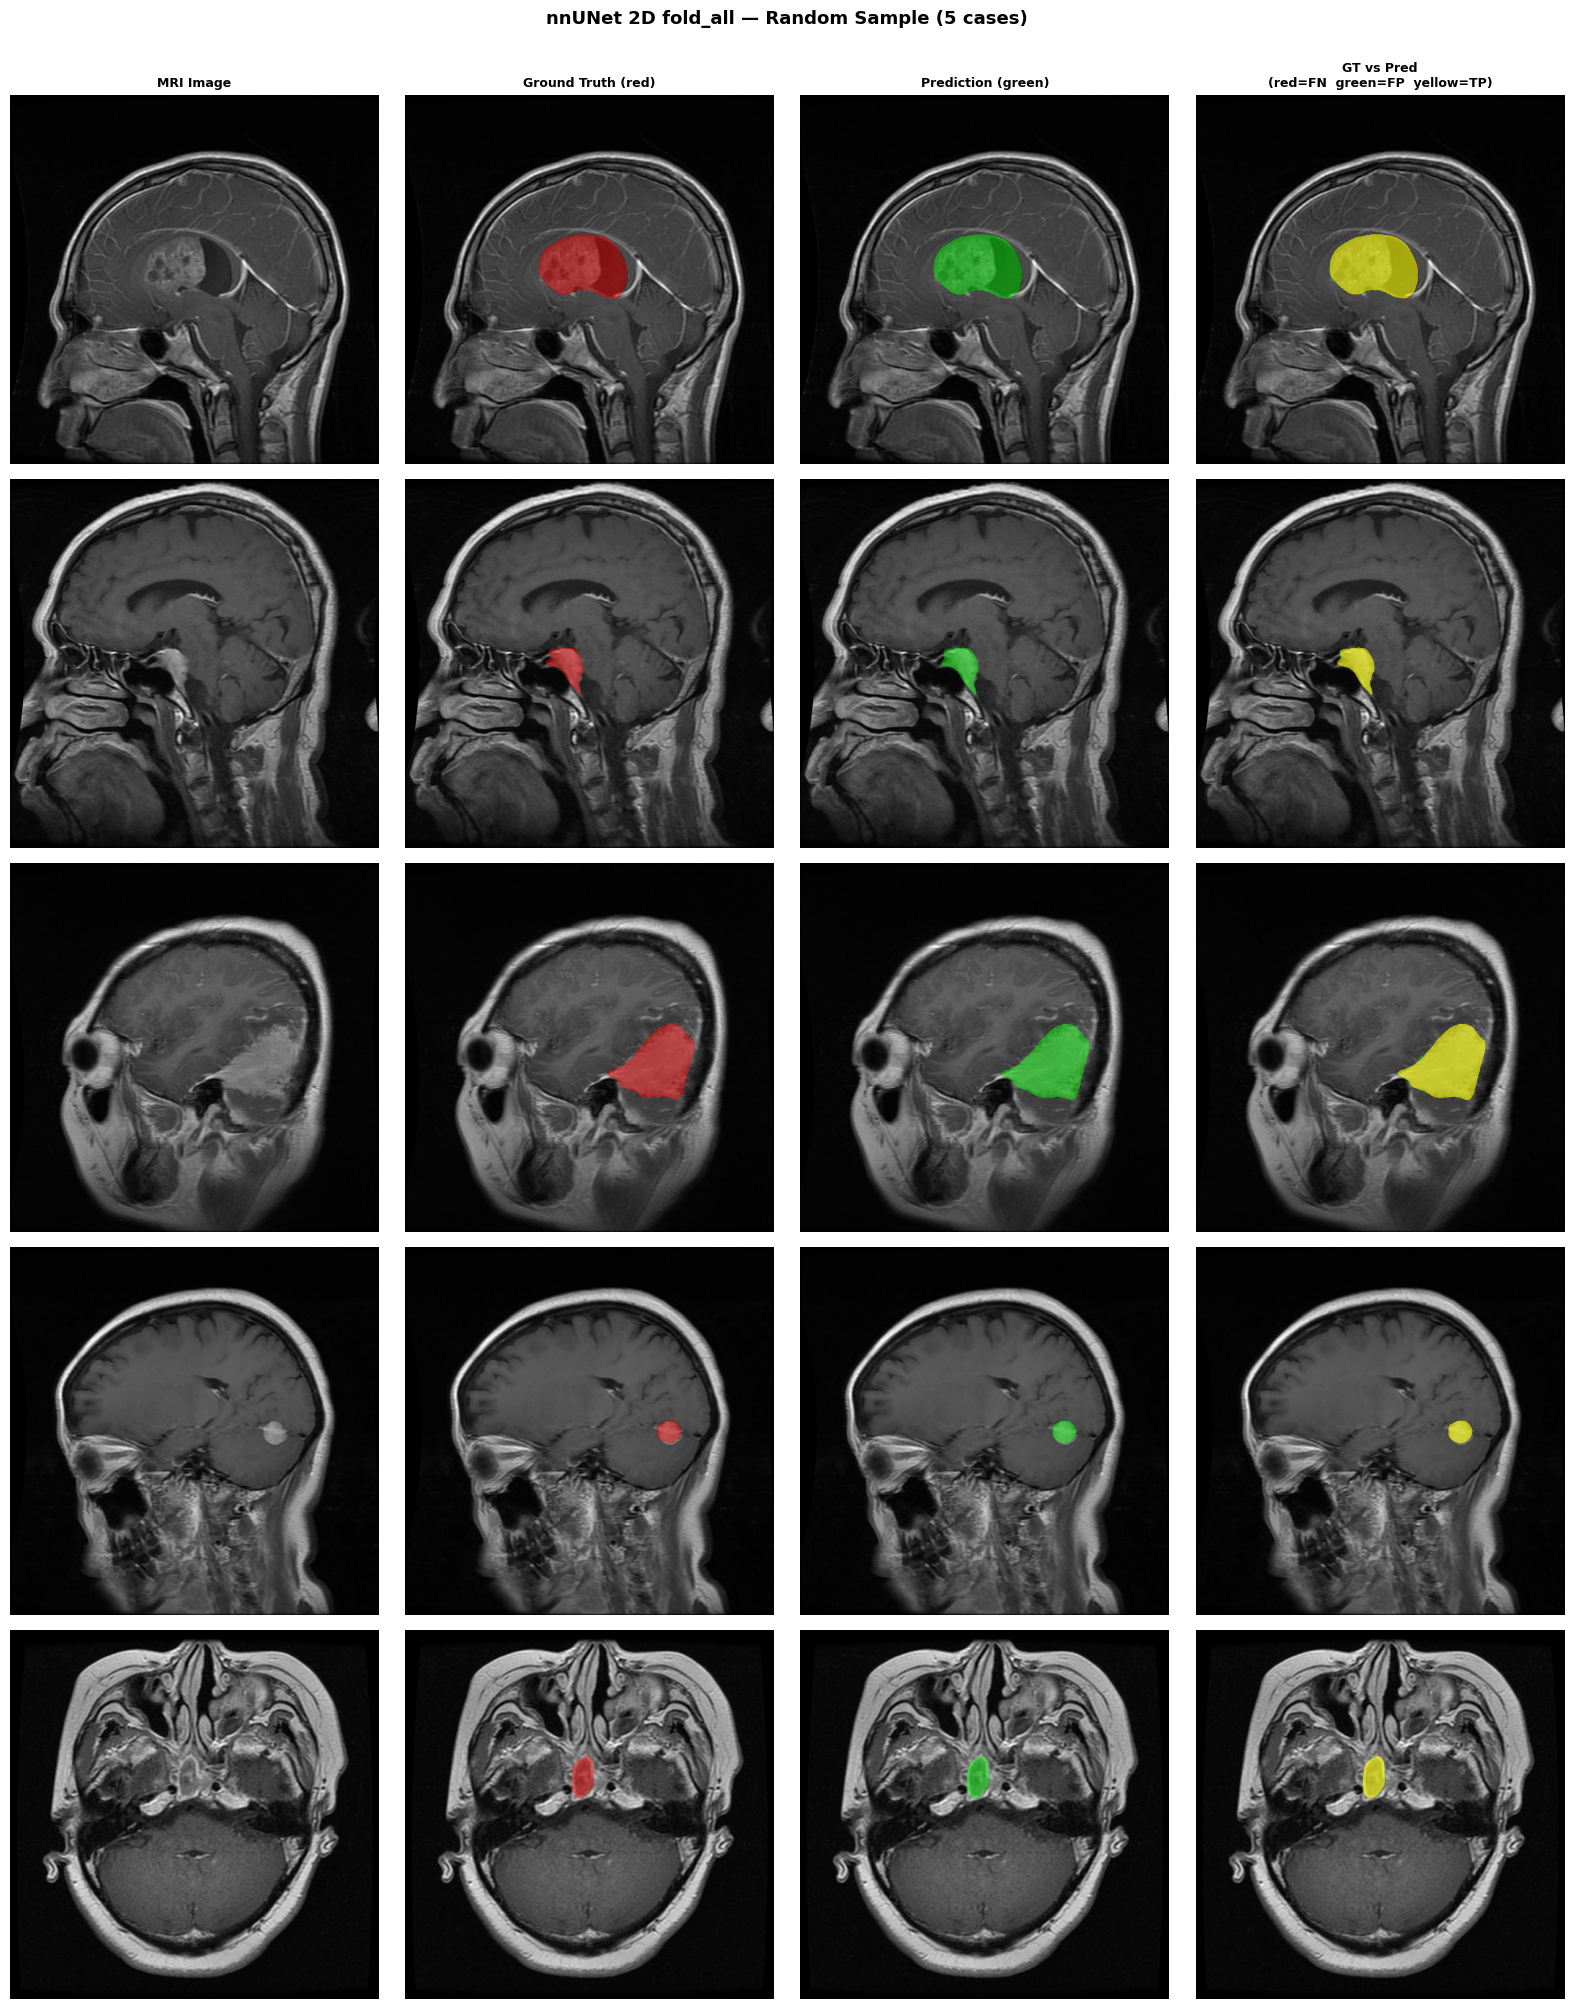

In [6]:
samples = random.sample(list(case_map.values()), min(5, len(case_map)))
plot_cases(samples, 'nnUNet 2D fold_all — Random Sample (5 cases)')


 ## Worst Predictions (Dice below threshold)

In [7]:
THRESHOLD = 0.3

worst_30 = sorted(
    [v for v in case_map.values() if v['dice'] is not None and v['dice'] < THRESHOLD],
    key=lambda x: x['dice']
)[:30]

print(f'Showing worst {len(worst_30)} cases (Dice < {THRESHOLD}):')
for i, c in enumerate(worst_30):
    print(f"  #{i+1:2d}  Dice={c['dice']:.4f}  IoU={c['iou']:.4f}  {Path(c['pred']).stem}")


Showing worst 0 cases (Dice < 0.3):


In [8]:
fig, axes = plt.subplots(len(worst_30), 4, figsize=(16, 4 * len(worst_30)))
col_titles = ['MRI Image', 'Ground Truth (red)', 'Prediction (green)',
              'GT vs Pred\n(red=FN  green=FP  yellow=TP)']
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=9, fontweight='bold')

for row, c in enumerate(worst_30):
    img      = np.array(Image.open(c['image']).convert('L'))
    gt_bin   = np.array(Image.open(c['mask']).convert('L')) > 0
    pred_bin = np.array(Image.open(c['pred']).convert('L')) > 0

    img_id   = Path(c['image']).stem
    dice_str = f"Dice={c['dice']:.3f}  IoU={c['iou']:.3f}"
    axes[row][0].imshow(img, cmap='gray')
    axes[row][0].set_ylabel(f"{img_id}\n{dice_str}", fontsize=8)
    axes[row][0].text(4, 14, img_id, color='yellow', fontsize=9, fontweight='bold')

    gt_overlay = np.zeros((*img.shape, 4), dtype=float)
    gt_overlay[gt_bin] = [1, 0, 0, 0.45]
    axes[row][1].imshow(img, cmap='gray')
    axes[row][1].imshow(gt_overlay)

    pred_overlay = np.zeros((*img.shape, 4), dtype=float)
    pred_overlay[pred_bin] = [0, 1, 0, 0.45]
    axes[row][2].imshow(img, cmap='gray')
    axes[row][2].imshow(pred_overlay)

    combined = np.zeros((*img.shape, 4), dtype=float)
    combined[gt_bin & ~pred_bin] = [1, 0, 0, 0.5]
    combined[pred_bin & ~gt_bin] = [0, 1, 0, 0.5]
    combined[gt_bin & pred_bin]  = [1, 1, 0, 0.6]
    axes[row][3].imshow(img, cmap='gray')
    axes[row][3].imshow(combined)

    for ax in axes[row]:
        ax.axis('off')

plt.suptitle(f'nnUNet 2D fold_all — Worst {len(worst_30)} Predictions (Dice < {THRESHOLD})',
             fontsize=13, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1600x0 with 0 Axes>